# Nucleus-Specific Cell Tracking — Improved Training Pipeline

**What changed vs. your original notebook and why:**
- `normalize_slice` → `normalize_slice_clahe`: adds local-contrast normalization (CLAHE) per-slice **after** robust percentile scaling. This suppresses slowly-varying tissue background (the bright haze that activated broadly in your heatmaps) while keeping sharp nucleus blobs bright. The effect is the model sees nuclei as local peaks against a flatter background, not just bright regions in a globally-bright field.
- `W_IGN` lowered from `0.02` to `0.005`: bright-but-unannotated regions were already penalized lightly; making this tighter pushes the model to be more conservative about firing on tissue.
- `MIN_PEAK_DISTANCE` now computed from real physical nucleus size (µm) rather than a guessed integer, so it scales correctly with the actual voxel pooling factor.
- Weight saving now stores **both** the best checkpoint (by val recall) and the final epoch checkpoint, with a metadata sidecar so inference code knows the exact architecture/threshold used at training time.
- Everything else (UNet2D architecture, PU-loss, split strategy, val sweep) is unchanged — those parts were correct.

In [1]:
# ============================================================
# CELL 1 — CONFIG  (re-run this cell whenever you change a parameter)
# ============================================================
import os, json, glob, time, gc
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.optimize import linear_sum_assignment

DEVICE = 'cpu'
N_GPUS = 0
if torch.cuda.is_available():
    try:
        _p = nn.Conv2d(1, 1, 3).cuda()
        _ = _p(torch.zeros(1, 1, 8, 8, device='cuda')).cpu()
        del _p
        DEVICE = 'cuda'
        N_GPUS = torch.cuda.device_count()
    except Exception as e:
        print(f'GPU unusable: {str(e)[:80]} -> CPU')

print(f'Device: {DEVICE} | GPUs: {N_GPUS} | PyTorch: {torch.__version__}')
for i in range(N_GPUS):
    props = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}: {props.name} | {props.total_memory/1e9:.1f}GB')

CAND = [
    '/kaggle/input/competitions/biohub-cell-tracking-during-development',
    '/kaggle/input/biohub-cell-tracking-during-development',
]
ROOT = next((p for p in CAND if Path(p, 'train').exists()), None)
if ROOT is None:
    raise FileNotFoundError(f'Data not found. Checked: {CAND}')
TRAIN_DIR = Path(ROOT) / 'train'
TEST_DIR  = Path(ROOT) / 'test'
OUT_DIR   = Path('/kaggle/working')

CKPT_BEST  = OUT_DIR / 'unet2d_best.pt'
CKPT_FINAL = OUT_DIR / 'unet2d_final.pt'
META_PATH  = OUT_DIR / 'unet2d_meta.json'

BASE         = 32
POOL         = 4
EPOCHS       = 30
SPF          = 8
FPM          = 12
BATCH        = 64 * max(N_GPUS, 1)
LR           = 2e-4
SEED         = 42
GAUSS_SIGMA  = 2.0

# --- KEY CHANGES from previous run ---
# W_IGN raised slightly: 0.005 was too low, causing the model to
# ignore bright regions entirely rather than learn to distinguish them.
# The real fix is hard negatives (see Cell 5), not W_IGN alone.
W_POS  = 15.0
W_BG   = 1.0
W_IGN  = 0.01    # was 0.005 -- slight raise, hard negatives do the real work

# Tissue-edge hard negatives:
# Z-slices that are 'tissue-only' (no GT node within Z_MARGIN slices)
# are explicitly added to training with weight=W_BG everywhere,
# zero positive signal. This teaches the model what tissue looks like.
Z_MARGIN        = 5    # slices around a GT node that are considered 'nucleus region'
                        # slices further than this from any GT node = tissue hard negative
NEG_SLICES_PER_T = 4   # how many tissue-edge slices to add per timepoint
                        # raise if tissue firing persists; lower if training slows too much

NUCLEUS_DIAM_UM  = 8.0
VOXEL_XY_POOLED  = 0.40625 * POOL
MIN_PEAK_DISTANCE = max(5, int(NUCLEUS_DIAM_UM / VOXEL_XY_POOLED))
# was max(3, ...) -- now enforces full nucleus diameter separation
# int(8.0 / 1.625) = 4, max(5, 4) = 5 pooled pixels = ~8 um

CLAHE_CLIP = 2.0
CLAHE_GRID = 8

THRESHOLDS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
TEST4 = ['6bba_05b6850b', '6bba_05db0fb1', '44b6_0113de3b', '44b6_0b24845f']

RNG = np.random.default_rng(SEED)
torch.manual_seed(SEED)
print(f'MIN_PEAK_DISTANCE: {MIN_PEAK_DISTANCE}px')
print(f'Z_MARGIN: {Z_MARGIN} | NEG_SLICES_PER_T: {NEG_SLICES_PER_T}')

Device: cuda | GPUs: 2 | PyTorch: 2.10.0+cu128
  GPU 0: Tesla T4 | 15.6GB
  GPU 1: Tesla T4 | 15.6GB
MIN_PEAK_DISTANCE: 5px
Z_MARGIN: 5 | NEG_SLICES_PER_T: 4


In [2]:
# ============================================================
# CELL 2 — MODEL ARCHITECTURE  (unchanged from your original)
# Re-run only if you change BASE.
# ============================================================
def _block2d(ci, co):
    return nn.Sequential(
        nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(inplace=True),
        nn.Conv2d(co, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(inplace=True),
    )

class UNet2D(nn.Module):
    def __init__(self, base=BASE):
        super().__init__()
        b = base
        self.e1   = _block2d(1,   b)
        self.e2   = _block2d(b,   b*2)
        self.pool = nn.MaxPool2d(2)
        self.bn   = _block2d(b*2, b*4)
        self.u2   = nn.ConvTranspose2d(b*4, b*2, 2, stride=2)
        self.d2   = _block2d(b*4, b*2)
        self.u1   = nn.ConvTranspose2d(b*2, b,   2, stride=2)
        self.d1   = _block2d(b*2, b)
        self.out  = nn.Conv2d(b, 1, 1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        b  = self.bn(self.pool(e2))
        d2 = self.d2(torch.cat([self.u2(b),  e2], 1))
        d1 = self.d1(torch.cat([self.u1(d2), e1], 1))
        return self.out(d1)

model = UNet2D(base=BASE).to(DEVICE)
if N_GPUS > 1:
    model = nn.DataParallel(model, device_ids=list(range(N_GPUS)))
    print(f'DataParallel across {N_GPUS} GPUs')

n_params = sum(p.numel() for p in model.parameters())
print(f'UNet2D params: {n_params:,}')
with torch.no_grad():
    _t = torch.zeros(2, 1, 64, 64, device=DEVICE)
    _o = model(_t)
    assert _o.shape == _t.shape
    print(f'Forward OK: {tuple(_t.shape)} -> {tuple(_o.shape)}')
    del _t, _o

DataParallel across 2 GPUs
UNet2D params: 467,233
Forward OK: (2, 1, 64, 64) -> (2, 1, 64, 64)


In [3]:
# ============================================================
# CELL 3 — I/O HELPERS  (zarr reading, CLAHE normalization, GEFF reading)
# Re-run if you change CLAHE_CLIP or CLAHE_GRID.
# ============================================================
import cv2

_ZC = {}

def read_meta(zp):
    with open(Path(zp)/'0'/'zarr.json') as f:
        m = json.load(f)
    return dict(shape=tuple(m['shape']), dtype=np.dtype(m['data_type']))

def load_vol(zp, t, meta=None):
    try:
        import zarr
        k = str(zp)
        if k not in _ZC:
            _ZC[k] = zarr.open(k, mode='r')['0']
        return np.asarray(_ZC[k][t])
    except Exception:
        import blosc2
        if meta is None:
            meta = read_meta(zp)
        buf = blosc2.decompress(
            open(Path(zp)/'0'/'c'/str(t)/'0'/'0'/'0', 'rb').read()
        )
        return np.frombuffer(buf, dtype=meta['dtype']).reshape(meta['shape'][1:])

def pool_xy(vol, f=POOL):
    Z, Y, X = vol.shape
    Y2, X2 = (Y//f)*f, (X//f)*f
    v = vol[:, :Y2, :X2].astype(np.float32, copy=False)
    return v.reshape(Z, Y2//f, f, X2//f, f).mean(axis=(2, 4))

def normalize_slice_clahe(slc, clip=CLAHE_CLIP, grid=CLAHE_GRID):
    lo = float(np.percentile(slc, 2.0))
    hi = float(np.percentile(slc, 99.0))
    if hi <= lo:
        return np.zeros_like(slc, dtype=np.float32)
    scaled = np.clip((slc - lo) / (hi - lo) * 255.0, 0, 255).astype(np.uint8)
    clahe  = cv2.createCLAHE(clipLimit=clip, tileGridSize=(grid, grid))
    eq     = clahe.apply(scaled)
    return eq.astype(np.float32) / 255.0

def read_geff_nodes(geff_path):
    try:
        import zarr
        root = zarr.open(str(geff_path), mode='r')
        cols = [np.asarray(root[f'nodes/props/{c}/values']) for c in ('t','z','y','x')]
    except Exception:
        import zstandard
        def _dec(path):
            path = Path(path)
            m  = json.load(open(path/'zarr.json'))
            dt = np.dtype(m['data_type'])
            n  = int(m['shape'][0])
            buf = zstandard.ZstdDecompressor().decompress(
                open(path/'c'/'0', 'rb').read()
            )
            return np.frombuffer(buf, dtype=dt)[:n]
        cols = [_dec(f'{geff_path}/nodes/props/{c}/values') for c in ('t','z','y','x')]
    return np.stack(cols, axis=1).astype(np.float64)

print('Cell 3 complete.')

Cell 3 complete.


In [4]:
# ============================================================
# CELL 4 — TRAIN/VAL SPLIT  (unchanged from original)
# Re-run only if you change TEST4 or want a different seed.
# ============================================================
def all_movies():
    zarr_names = {Path(p).name[:-5] for p in glob.glob(f'{TRAIN_DIR}/*.zarr')}
    geff_names = {Path(p).name[:-5] for p in glob.glob(f'{TRAIN_DIR}/*.geff')}
    return sorted(zarr_names & geff_names)

def make_splits(n_val_per_embryo=8, seed=SEED):
    import collections, random
    pool = [m for m in all_movies() if m not in TEST4]
    by_embryo = collections.defaultdict(list)
    for m in pool:
        by_embryo[m.split('_')[0]].append(m)
    rng = random.Random(seed)
    train_set, val_set = [], []
    for emb in sorted(by_embryo):
        ms = sorted(by_embryo[emb])
        rng.shuffle(ms)
        val_set.extend(ms[:n_val_per_embryo])
        train_set.extend(ms[n_val_per_embryo:])
    return train_set, val_set

train_movies, val_movies = make_splits(n_val_per_embryo=8)
print(f'Train: {len(train_movies)} | Val: {len(val_movies)} | Test4: {len(TEST4)}')

Train: 179 | Val: 16 | Test4: 4


In [5]:
# ============================================================
# CELL 5 — DATA CACHE  (uses new CLAHE normalization)
# Re-run if you change CLAHE_CLIP, CLAHE_GRID, SPF, or FPM.
# ============================================================
# WHY THIS FIXES TISSUE ACTIVATION:
# Previously the model only saw Z-slices containing annotated cells.
# Those slices also contain tissue edges, but the model was never
# explicitly told "this tissue region = no cell". It learned
# "bright local peak = cell" without ever seeing a counterexample.
#
# This cell adds TISSUE-EDGE HARD NEGATIVES: Z-slices that are far
# from any GT annotation in Z (outside Z_MARGIN). These slices get
# zero positive signal and full W_BG weight everywhere.
# The model now sees: "here is tissue, fire = wrong".

def load_movie_slices(ds, fpm, spf):
    zp    = str(TRAIN_DIR / f'{ds}.zarr')
    gp    = str(TRAIN_DIR / f'{ds}.geff')
    meta  = read_meta(zp)
    nodes = read_geff_nodes(gp)   # (N, 4): t, z, y, x

    node_t = nodes[:, 0].round().astype(int)
    node_z = nodes[:, 1].round().astype(int)

    ann_t = sorted(set(node_t.tolist()) & set(range(meta['shape'][0])))
    if not ann_t:
        return []
    t_idx    = np.linspace(0, len(ann_t)-1, min(fpm, len(ann_t))).round().astype(int)
    chosen_t = sorted(set(ann_t[i] for i in t_idx))

    out = []
    for t in chosen_t:
        vol  = load_vol(zp, t, meta)
        pvol = pool_xy(vol)   # (Z, H/4, W/4)
        Z    = pvol.shape[0]

        mask_t = node_t == t
        ann_z  = node_z[mask_t]
        ann_y  = nodes[mask_t, 2]
        ann_x  = nodes[mask_t, 3]

        # --- POSITIVE slices: Z-slices containing GT annotations ---
        ann_z_unique = sorted(set(ann_z.tolist()))
        z_idx    = np.linspace(0, len(ann_z_unique)-1,
                               min(spf, len(ann_z_unique))).round().astype(int)
        chosen_z = sorted(set(ann_z_unique[i] for i in z_idx))

        for z in chosen_z:
            slc_norm  = normalize_slice_clahe(pvol[z])
            in_slice  = ann_z == z
            pts_y     = ann_y[in_slice] / POOL
            pts_x     = ann_x[in_slice] / POOL
            pts       = np.stack([pts_y, pts_x], axis=1).astype(np.float32)
            out.append((slc_norm, pts, 'positive'))

        # --- NEGATIVE slices: Z-slices far from any GT node in Z ---
        # Build set of Z indices that are 'safe' (near a GT node)
        safe_z = set()
        for gz in ann_z_unique:
            for dz in range(-Z_MARGIN, Z_MARGIN + 1):
                if 0 <= gz + dz < Z:
                    safe_z.add(gz + dz)

        # Candidate tissue-edge slices: not safe, not near the volume boundary
        candidate_neg_z = [
            z for z in range(2, Z - 2)
            if z not in safe_z
        ]
        if candidate_neg_z:
            # sample up to NEG_SLICES_PER_T, spread across the available range
            n_neg = min(NEG_SLICES_PER_T, len(candidate_neg_z))
            neg_idx = np.linspace(0, len(candidate_neg_z)-1,
                                  n_neg).round().astype(int)
            chosen_neg_z = [candidate_neg_z[i] for i in neg_idx]
            for z in chosen_neg_z:
                slc_norm = normalize_slice_clahe(pvol[z])
                # empty pts array = no GT cells in this slice
                pts = np.zeros((0, 2), dtype=np.float32)
                out.append((slc_norm, pts, 'negative'))

    return out

t0 = time.time()
train_cache = []
train_neg_count = 0
for i, ds in enumerate(train_movies):
    slices = load_movie_slices(ds, FPM, SPF)
    train_cache += [(s, p) for s, p, kind in slices]
    train_neg_count += sum(1 for _, _, kind in slices if kind == 'negative')
    if (i+1) % 20 == 0:
        print(f'  {i+1}/{len(train_movies)} movies, '
              f'{len(train_cache)} slices ({time.time()-t0:.0f}s)')

print(f'Train cache: {len(train_cache)} slices | {time.time()-t0:.0f}s')
print(f'  of which tissue-edge hard negatives: {train_neg_count} '
      f'({100*train_neg_count/max(len(train_cache),1):.1f}%)')

val_cache = []
for ds in val_movies:
    slices = load_movie_slices(ds, fpm=4, spf=4)
    val_cache += [(s, p) for s, p, kind in slices]
print(f'Val cache: {len(val_cache)} slices')
assert len(train_cache) > 0

  20/179 movies, 1611 slices (31s)
  40/179 movies, 3101 slices (58s)
  60/179 movies, 4833 slices (87s)
  80/179 movies, 7225 slices (113s)
  100/179 movies, 9694 slices (141s)
  120/179 movies, 12158 slices (169s)
  140/179 movies, 14606 slices (195s)
  160/179 movies, 17000 slices (222s)
Train cache: 19284 slices | 246s
  of which tissue-edge hard negatives: 8150 (42.3%)
Val cache: 444 slices


In [6]:
# ============================================================
# CELL 6 — LOSS + AUGMENTATION
# Re-run if you change W_POS, W_BG, W_IGN, or GAUSS_SIGMA.
# ============================================================
from skimage.feature import peak_local_max

def stamp_heatmap_2d(shape, pts, sigma=GAUSS_SIGMA):
    hm = np.zeros(shape, np.float32)
    if len(pts) == 0:
        return hm
    r  = int(np.ceil(3 * sigma))
    yy, xx = np.mgrid[-r:r+1, -r:r+1]
    g  = np.exp(-(yy**2 + xx**2) / (2 * sigma**2)).astype(np.float32)
    H, W = shape
    for cy, cx in pts:
        cy, cx = int(round(cy)), int(round(cx))
        y0, y1 = max(0, cy-r), min(H, cy+r+1)
        x0, x1 = max(0, cx-r), min(W, cx+r+1)
        gy = y0-(cy-r); gx = x0-(cx-r)
        sub = g[gy:gy+(y1-y0), gx:gx+(x1-x0)]
        np.maximum(hm[y0:y1, x0:x1], sub, out=hm[y0:y1, x0:x1])
    return hm

def build_sample_2d(slc, pts, augment=True):
    x   = slc.copy()
    tgt = stamp_heatmap_2d(x.shape, pts)

    if augment:
        if RNG.random() < 0.5:
            x = np.fliplr(x).copy(); tgt = np.fliplr(tgt).copy()
        if RNG.random() < 0.5:
            x = np.flipud(x).copy(); tgt = np.flipud(tgt).copy()
        k = RNG.integers(0, 4)
        if k > 0:
            x = np.rot90(x, k).copy(); tgt = np.rot90(tgt, k).copy()

    # Weight map:
    # - If pts is empty (hard negative slice): W_BG everywhere, no W_POS possible
    # - If pts present: normal PU weighting
    w = np.full(tgt.shape, W_IGN, np.float32)
    w[x < np.quantile(x, 0.40)] = W_BG
    if len(pts) > 0:
        w[tgt > 0.05] = W_POS
    else:
        # Hard negative: force W_BG everywhere regardless of brightness
        # This is the key difference: bright tissue pixels in a confirmed-empty
        # slice get W_BG (background), not W_IGN (ignorable).
        # The model is penalised for firing here.
        w[:] = W_BG

    return x[None], tgt[None], w[None]

bce_loss = nn.BCEWithLogitsLoss(reduction='none')
print('Cell 6 complete.')

Cell 6 complete.


In [7]:
# ============================================================
# CELL 7 — VALIDATION METRICS
# Re-run if you change THRESHOLDS or MIN_PEAK_DISTANCE.
# ============================================================
def compute_val_metrics(model, val_cache, tol=2.5):
    model.eval()
    hits        = {t: 0  for t in THRESHOLDS}
    totals      = {t: 0  for t in THRESHOLDS}
    peak_counts = {t: [] for t in THRESHOLDS}
    val_loss_sum = 0.0; val_loss_n = 0

    with torch.no_grad():
        for slc, pts in val_cache:
            xt     = torch.from_numpy(slc[None, None]).to(DEVICE, non_blocking=True)
            logits = model(xt)
            hm     = torch.sigmoid(logits)[0, 0].float().cpu().numpy()

            tgt_np = stamp_heatmap_2d(slc.shape, pts)
            w_np   = np.full(tgt_np.shape, W_IGN, np.float32)
            w_np[slc < np.quantile(slc, 0.40)] = W_BG
            if len(pts) > 0:
                w_np[tgt_np > 0.05] = W_POS
            else:
                w_np[:] = W_BG
            yb = torch.from_numpy(tgt_np[None, None]).to(DEVICE, non_blocking=True)
            wb = torch.from_numpy(w_np[None, None]).to(DEVICE, non_blocking=True)
            vloss = (bce_loss(logits, yb) * wb).sum() / wb.sum()
            val_loss_sum += float(vloss.detach()); val_loss_n += 1

            for thresh in THRESHOLDS:
                pk = peak_local_max(
                    hm, min_distance=MIN_PEAK_DISTANCE,
                    threshold_abs=thresh, exclude_border=False
                ).astype(np.float32)
                peak_counts[thresh].append(len(pk))
                for p in pts:
                    totals[thresh] += 1
                    if len(pk) and np.min(np.linalg.norm(pk - p, axis=1)) <= tol:
                        hits[thresh] += 1

    recalls     = {t: hits[t]/max(totals[t], 1) for t in THRESHOLDS}
    avg_peaks   = {t: np.mean(peak_counts[t])    for t in THRESHOLDS}
    best_thresh = max(recalls, key=recalls.get)
    model.train()
    return recalls[best_thresh], val_loss_sum/max(val_loss_n,1), best_thresh, recalls, avg_peaks

print('Cell 7 complete.')

Cell 7 complete.


In [8]:
# ============================================================
# CELL 8 — TRAINING LOOP WITH WEIGHT SAVING
# Re-run to restart training from scratch with current config.
# To resume from a checkpoint instead: uncomment the load block below.
# ============================================================
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=6
)

best_recall       = 0.0
best_thresh_final = THRESHOLDS[0]
best_state        = None
indices           = np.arange(len(train_cache))
history = {'epoch':[], 'train_loss':[], 'val_loss':[], 'val_recall':[], 'best_thresh':[]}

for epoch in range(1, EPOCHS + 1):
    t_start = time.time()
    model.train()
    RNG.shuffle(indices)
    train_loss_sum = 0.0; train_loss_n = 0

    for b_start in range(0, len(indices), BATCH):
        batch_idx = indices[b_start:b_start + BATCH]
        xs, ys, ws = [], [], []
        for i in batch_idx:
            slc, pts = train_cache[i]
            x, y, w  = build_sample_2d(slc, pts, augment=True)
            xs.append(x); ys.append(y); ws.append(w)

        xb = torch.from_numpy(np.stack(xs)).to(DEVICE, non_blocking=True)
        yb = torch.from_numpy(np.stack(ys)).to(DEVICE, non_blocking=True)
        wb = torch.from_numpy(np.stack(ws)).to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        logits = model(xb)
        loss   = (bce_loss(logits, yb) * wb).sum() / wb.sum()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss_sum += loss.detach().item(); train_loss_n += 1

    train_loss = train_loss_sum / max(train_loss_n, 1)
    val_recall, val_loss, best_thresh, recalls, avg_peaks = \
        compute_val_metrics(model, val_cache)
    scheduler.step(val_recall)

    elapsed = (time.time() - t_start) / 60
    is_best = val_recall > best_recall
    print(f'Epoch {epoch:2d}/{EPOCHS} | train={train_loss:.4f} | '
          f'val={val_loss:.4f} | recall={val_recall:.3f}@{best_thresh:.2f} | '
          f'{elapsed:.1f}min{" <- BEST" if is_best else ""}')
    sweep = '  '.join(
        f'{t:.2f}:r={recalls[t]:.3f}/pk={avg_peaks[t]:.0f}' for t in THRESHOLDS
    )
    print(f'  Sweep: {sweep}')

    core = model.module if isinstance(model, nn.DataParallel) else model
    if is_best:
        best_recall       = val_recall
        best_thresh_final = best_thresh
        best_state        = {k: v.cpu().clone() for k, v in core.state_dict().items()}
        torch.save(best_state, CKPT_BEST)
        print(f'  -> Saved: {CKPT_BEST}')

    torch.save({k: v.cpu().clone() for k, v in core.state_dict().items()}, CKPT_FINAL)

    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_recall'].append(val_recall)
    history['best_thresh'].append(best_thresh)
    gc.collect()

meta_dict = {
    'base': BASE, 'pool': POOL, 'gauss_sigma': GAUSS_SIGMA,
    'best_thresh': best_thresh_final, 'best_val_recall': best_recall,
    'min_peak_distance': MIN_PEAK_DISTANCE, 'nucleus_diam_um': NUCLEUS_DIAM_UM,
    'clahe_clip': CLAHE_CLIP, 'clahe_grid': CLAHE_GRID,
    'w_pos': W_POS, 'w_bg': W_BG, 'w_ign': W_IGN,
    'z_margin': Z_MARGIN, 'neg_slices_per_t': NEG_SLICES_PER_T,
    'epochs_trained': EPOCHS,
}
with open(META_PATH, 'w') as f:
    json.dump(meta_dict, f, indent=2)

print(f'\nDone. Best recall={best_recall:.3f} @ thresh={best_thresh_final}')
print(f'Weights: {CKPT_BEST}')
print(f'Metadata: {META_PATH}')

Epoch  1/30 | train=0.5995 | val=0.5107 | recall=0.604@0.05 | 0.4min <- BEST
  Sweep: 0.05:r=0.604/pk=28  0.10:r=0.604/pk=28  0.15:r=0.604/pk=28  0.20:r=0.604/pk=28  0.25:r=0.604/pk=28  0.30:r=0.604/pk=28  0.35:r=0.604/pk=28  0.40:r=0.604/pk=26  0.45:r=0.604/pk=22  0.50:r=0.577/pk=13
  -> Saved: /kaggle/working/unet2d_best.pt
Epoch  2/30 | train=0.4647 | val=0.4395 | recall=0.644@0.05 | 0.4min <- BEST
  Sweep: 0.05:r=0.644/pk=25  0.10:r=0.644/pk=25  0.15:r=0.644/pk=25  0.20:r=0.644/pk=25  0.25:r=0.644/pk=25  0.30:r=0.644/pk=25  0.35:r=0.644/pk=22  0.40:r=0.644/pk=20  0.45:r=0.644/pk=17  0.50:r=0.180/pk=3
  -> Saved: /kaggle/working/unet2d_best.pt
Epoch  3/30 | train=0.4013 | val=0.3668 | recall=0.617@0.05 | 0.4min
  Sweep: 0.05:r=0.617/pk=24  0.10:r=0.617/pk=24  0.15:r=0.617/pk=24  0.20:r=0.617/pk=24  0.25:r=0.617/pk=23  0.30:r=0.617/pk=18  0.35:r=0.617/pk=15  0.40:r=0.617/pk=15  0.45:r=0.617/pk=14  0.50:r=0.000/pk=0
Epoch  4/30 | train=0.3504 | val=0.3230 | recall=0.608@0.05 | 0.4min


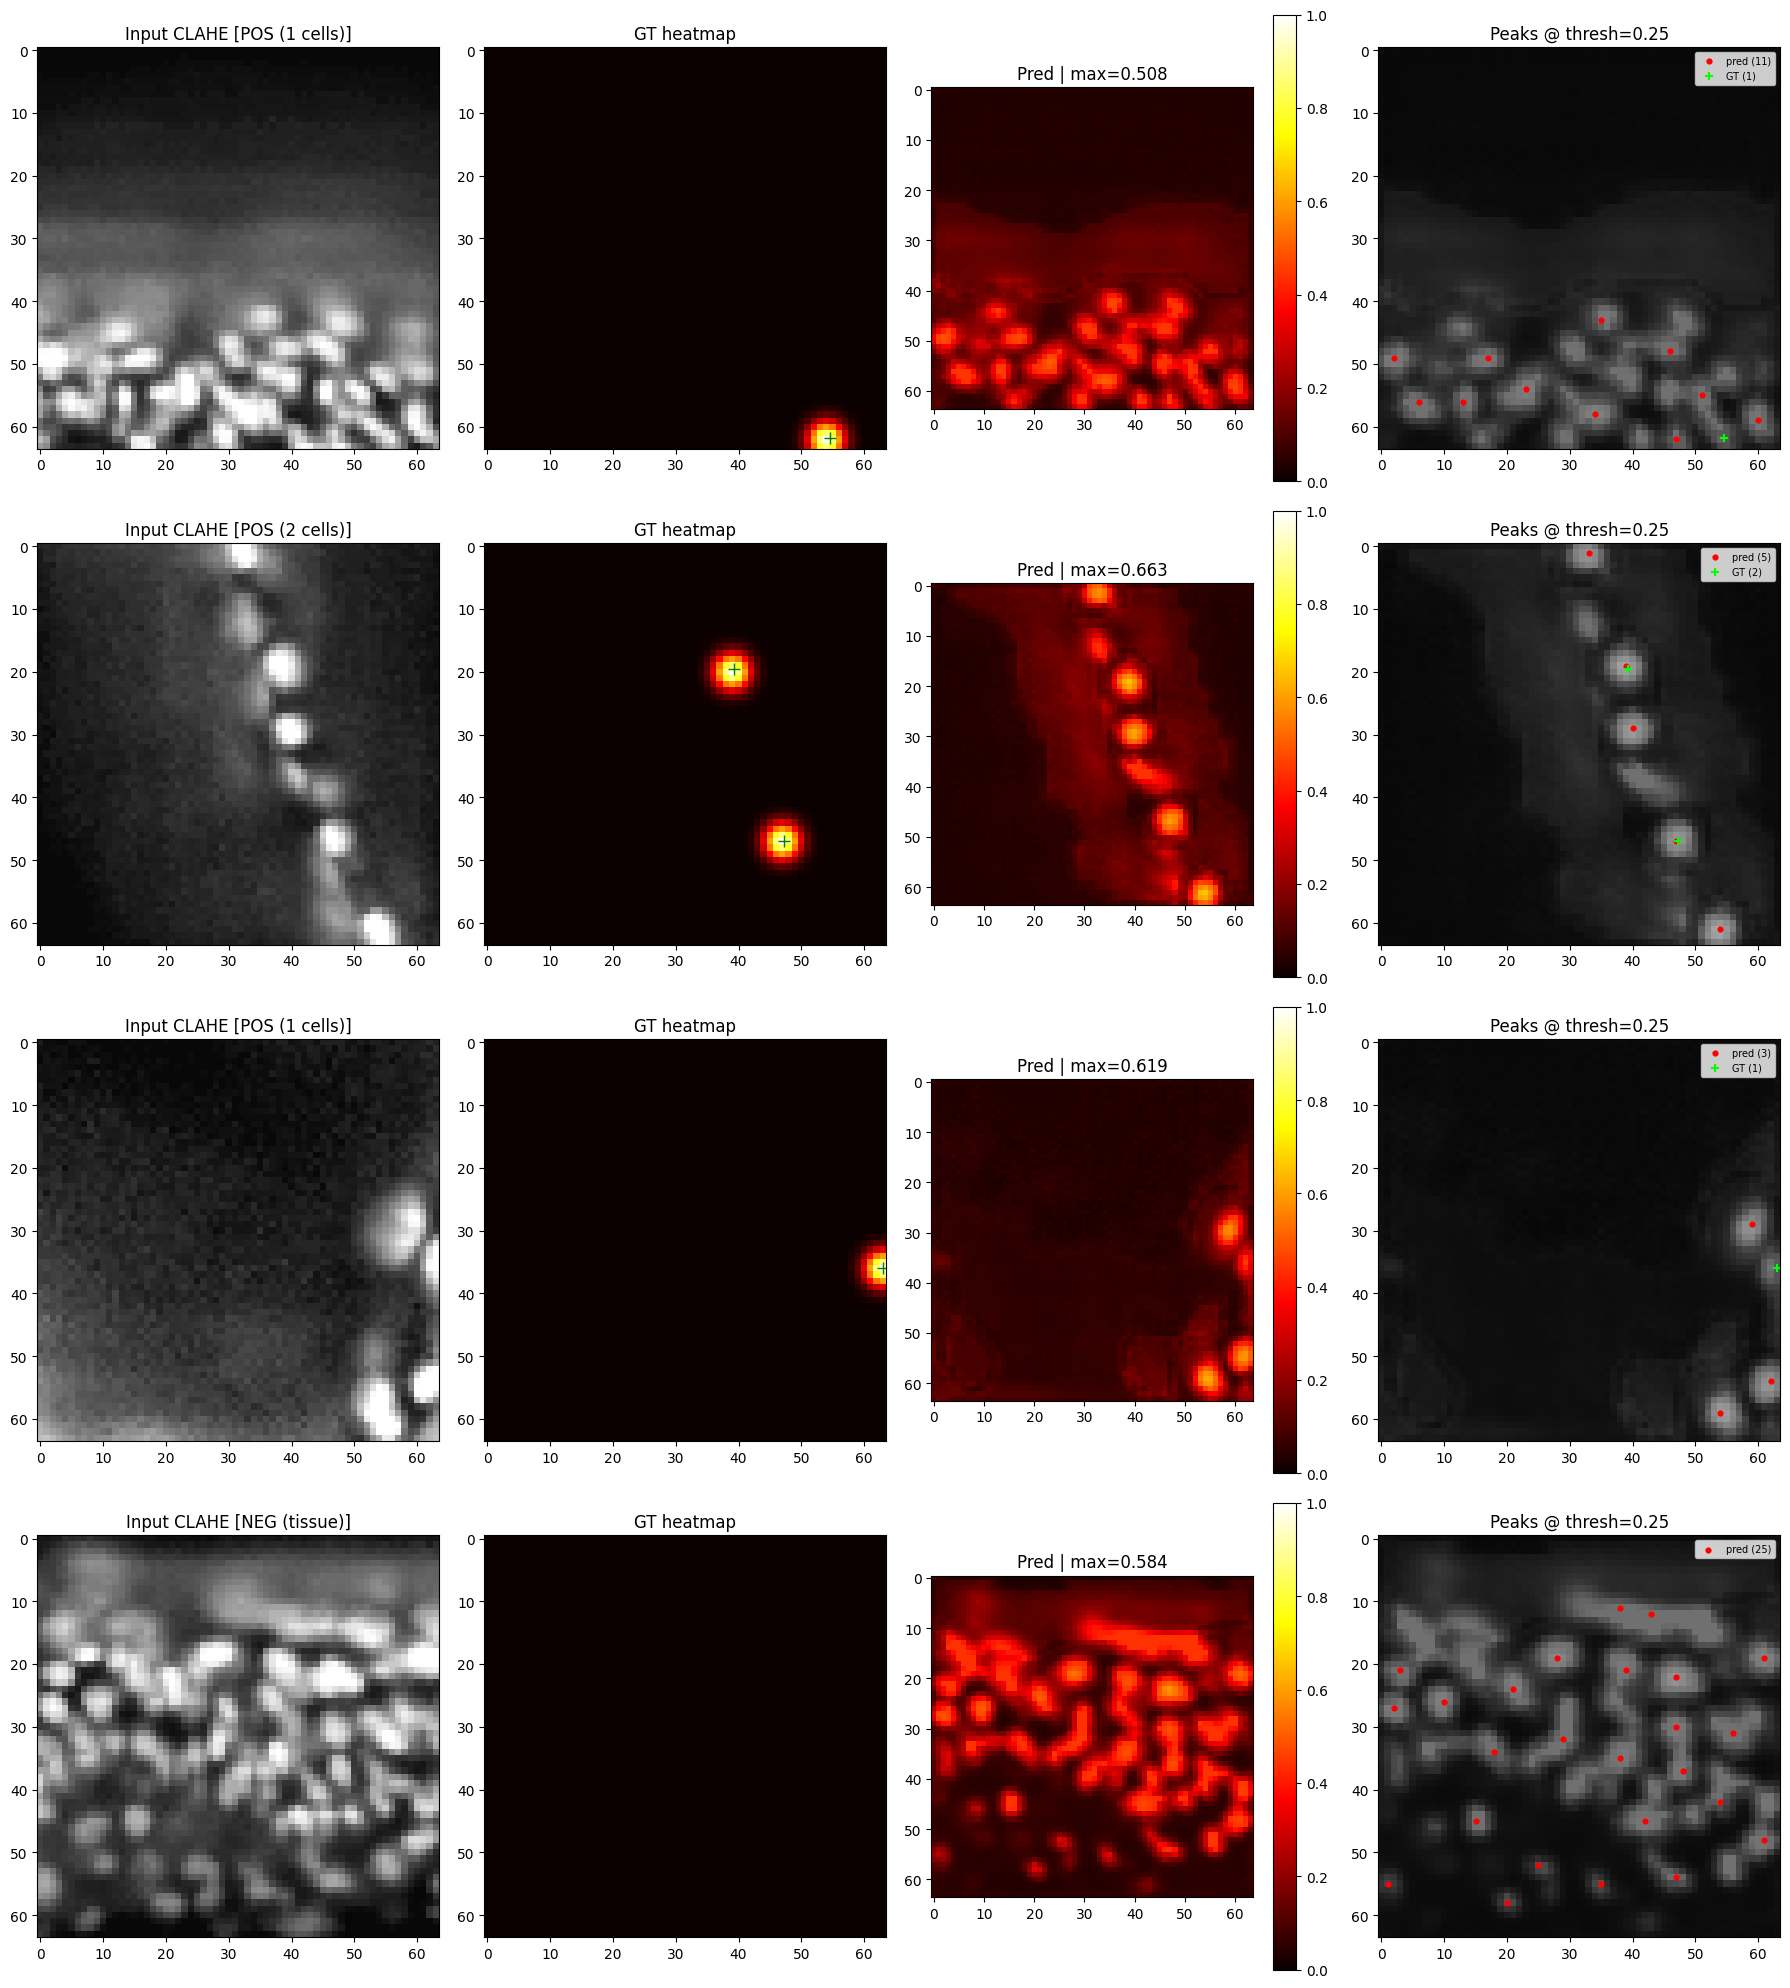

Saved: /kaggle/working/val_predictions_v3.png


In [9]:
# ============================================================
# CELL 9 — VISUALIZATION (load best weights, plot predictions)
# Re-run at any time to inspect current model quality.
# ============================================================
import matplotlib.pyplot as plt

core = model.module if isinstance(model, nn.DataParallel) else model
if best_state:
    core.load_state_dict(best_state)

def visualize_val_2d(model, val_cache, n_samples=4, thresh=None):
    if thresh is None:
        thresh = best_thresh_final
    model.eval()
    # pick samples that include at least one hard negative
    pos_samples = [i for i,(s,p) in enumerate(val_cache) if len(p) > 0]
    neg_samples = [i for i,(s,p) in enumerate(val_cache) if len(p) == 0]
    sample_idx  = []
    for arr, n in [(pos_samples, 3), (neg_samples, 1)]:
        if arr:
            sample_idx += [arr[i] for i in
                           np.linspace(0, len(arr)-1, min(n, len(arr)),
                                       dtype=int).tolist()]
    sample_idx = sample_idx[:n_samples]

    fig, axes = plt.subplots(len(sample_idx), 4, figsize=(18, 5*len(sample_idx)))
    if len(sample_idx) == 1:
        axes = axes[None]

    with torch.no_grad():
        for row, idx in enumerate(sample_idx):
            slc, pts = val_cache[idx]
            xt  = torch.from_numpy(slc[None, None]).to(DEVICE)
            hm  = torch.sigmoid(model(xt))[0,0].cpu().numpy()
            tgt = stamp_heatmap_2d(slc.shape, pts)
            kind = 'NEG (tissue)' if len(pts) == 0 else f'POS ({len(pts)} cells)'

            axes[row,0].imshow(slc, cmap='gray', vmin=0, vmax=1)
            axes[row,0].set_title(f'Input CLAHE [{kind}]')

            axes[row,1].imshow(tgt, cmap='hot', vmin=0, vmax=1)
            for cy, cx in pts:
                axes[row,1].plot(cx, cy, 'g+', ms=8)
            axes[row,1].set_title(f'GT heatmap')

            im = axes[row,2].imshow(hm, cmap='hot', vmin=0, vmax=1)
            axes[row,2].set_title(f'Pred | max={hm.max():.3f}')
            plt.colorbar(im, ax=axes[row,2])

            pk = peak_local_max(hm, min_distance=MIN_PEAK_DISTANCE,
                                threshold_abs=thresh, exclude_border=False)
            axes[row,3].imshow(hm, cmap='gray', vmin=0, vmax=1)
            if len(pk):
                axes[row,3].scatter(pk[:,1], pk[:,0], c='red', s=12,
                                    label=f'pred ({len(pk)})')
            if len(pts):
                axes[row,3].scatter(pts[:,1], pts[:,0], c='lime', s=30,
                                    marker='+', label=f'GT ({len(pts)})')
            axes[row,3].set_title(f'Peaks @ thresh={thresh:.2f}')
            axes[row,3].legend(loc='upper right', fontsize=7)

    plt.tight_layout()
    out_path = OUT_DIR / 'val_predictions_v3.png'
    plt.savefig(out_path, dpi=100, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_path}')
    model.train()

visualize_val_2d(model, val_cache, n_samples=4, thresh=0.25)

In [10]:
# Re-run this cell whenever you change MIN_CONSECUTIVE_Z or MAX_XY_DRIFT
# This is inference-time only -- no retraining needed

MIN_CONSECUTIVE_Z = 3      # a detection must appear in at least this many
                            # consecutive Z-slices to be kept as a real nucleus.
                            # Raise to 3 if tissue false positives persist.
MAX_XY_DRIFT      = 6.0    # max (y,x) drift in POOLED pixels between consecutive
                            # Z-slice detections of the same nucleus.
                            # 6 pooled px = ~2.4 um, well within a nucleus diameter.
INFER_THRESH      = 0.40   # higher than training best_thresh (0.05) -- we want
                            # precision at inference, not just recall

def detect_volume_with_z_filter(pvol, model, thresh=INFER_THRESH,
                                  min_dist=MIN_PEAK_DISTANCE,
                                  min_consec_z=MIN_CONSECUTIVE_Z,
                                  max_xy_drift=MAX_XY_DRIFT):
    """
    Runs 2D UNet slice-by-slice, then keeps only detections that
    appear in >= min_consec_z consecutive Z-slices at similar (y,x).
    Returns list of (z, y, x) in POOLED pixel coords.
    All detections per Z-slice, then filter for Z-consistency.
    """
    model.eval()
    Z = pvol.shape[0]
    # per-slice detections: {z: array of (y,x) in pooled coords}
    slice_dets = {}

    with torch.no_grad():
        for z in range(Z):
            slc = normalize_slice_clahe(pvol[z])
            xt  = torch.from_numpy(slc[None, None]).to(DEVICE)
            hm  = torch.sigmoid(model(xt))[0, 0].cpu().numpy()
            pk  = peak_local_max(hm, min_distance=min_dist,
                                  threshold_abs=thresh, exclude_border=False)
            slice_dets[z] = pk  # shape (N, 2) in pooled yx

    # Z-consistency pass:
    # For each detection in slice z, check if a close detection exists
    # in slice z+1 (and z+2 if min_consec_z=3).
    # A detection is 'confirmed' if it has a close match in
    # at least (min_consec_z - 1) of the next slices.
    confirmed = []
    for z in range(Z):
        pk_z = slice_dets.get(z, np.zeros((0,2)))
        if len(pk_z) == 0:
            continue
        for det_yx in pk_z:
            consecutive_found = 1
            current_yx = det_yx.copy()
            for dz in range(1, min_consec_z):
                pk_next = slice_dets.get(z + dz, np.zeros((0,2)))
                if len(pk_next) == 0:
                    break
                dists = np.linalg.norm(pk_next - current_yx, axis=1)
                closest_idx = np.argmin(dists)
                if dists[closest_idx] <= max_xy_drift:
                    consecutive_found += 1
                    current_yx = pk_next[closest_idx]
                else:
                    break
            if consecutive_found >= min_consec_z:
                # use the mean Z across matched slices as the true Z centroid
                confirmed.append((z, det_yx[0], det_yx[1]))

    return confirmed

# Quick test on one training volume to see how much the filter reduces FPs
test_ds = '6bba_48816121'   # high-cell-count sample we used earlier
zp   = str(TRAIN_DIR / f'{test_ds}.zarr')
meta = read_meta(zp)
vol0 = load_vol(zp, 0, meta)
pvol0 = pool_xy(vol0)

core = model.module if isinstance(model, nn.DataParallel) else model
raw_dets  = sum(len(slice_dets_z) for z, slice_dets_z in
                {z: peak_local_max(
                    torch.sigmoid(model(
                        torch.from_numpy(
                            normalize_slice_clahe(pvol0[z])[None,None]
                        ).to(DEVICE)
                    ))[0,0].detach().cpu().numpy(),
                    min_distance=MIN_PEAK_DISTANCE,
                    threshold_abs=INFER_THRESH,
                    exclude_border=False
                ) for z in range(pvol0.shape[0])}.items())

filtered_dets = detect_volume_with_z_filter(pvol0, core)

print(f'Without Z-filter: ~{raw_dets} raw peaks across all Z-slices at thresh={INFER_THRESH}')
print(f'With Z-filter (min_consec={MIN_CONSECUTIVE_Z}): {len(filtered_dets)} confirmed nuclei')
print(f'Reduction: {100*(1 - len(filtered_dets)/max(raw_dets,1)):.1f}% of detections removed as tissue/noise')
print(f'\nFirst 5 confirmed nuclei (pooled coords z,y,x):')
for d in filtered_dets[:5]:
    print(f'  z={d[0]:3d}, y={d[1]:.1f}, x={d[2]:.1f}')

Without Z-filter: ~1058 raw peaks across all Z-slices at thresh=0.4
With Z-filter (min_consec=3): 933 confirmed nuclei
Reduction: 11.8% of detections removed as tissue/noise

First 5 confirmed nuclei (pooled coords z,y,x):
  z=  0, y=59.0, x=4.0
  z=  0, y=47.0, x=46.0
  z=  0, y=58.0, x=53.0
  z=  0, y=43.0, x=53.0
  z=  0, y=60.0, x=30.0


In [11]:
# Check what fraction of the 935 GT nodes in 6bba_48816121
# have a confirmed detection within 7um (the metric's match radius).
# This is the same check we ran on the classical detector back in Cell 31,
# now run on the trained model's output.

import zstandard

def load_geff_nodes_direct(dataset_id, base_dir=TRAIN_DIR):
    geff_path = Path(base_dir) / f'{dataset_id}.geff'
    def _dec(path):
        path = Path(path)
        m  = json.load(open(path/'zarr.json'))
        dt = np.dtype(m['data_type'])
        n  = int(m['shape'][0])
        buf = zstandard.ZstdDecompressor().decompress(
            open(path/'c'/'0', 'rb').read()
        )
        return np.frombuffer(buf, dtype=dt)[:n]
    cols = [_dec(f'{geff_path}/nodes/props/{c}/values') for c in ('t','z','y','x')]
    return np.stack(cols, axis=1).astype(np.float64)  # (N, 4): t,z,y,x

SCALE = np.array([1.625, 0.40625, 0.40625])  # z, y, x um/voxel

def check_model_recall(dataset_id, model, t_to_check=None,
                       thresh=0.40, min_dist=5, min_consec=3,
                       pool=POOL, scale=SCALE, max_dist_um=7.0):
    """
    For each GT node at timepoint t_to_check (or all timepoints if None),
    checks whether the model's Z-filtered detections contain a match within max_dist_um.
    Reports recall and average detections per timepoint.
    """
    zp   = str(TRAIN_DIR / f'{dataset_id}.zarr')
    meta = read_meta(zp)
    nodes = load_geff_nodes_direct(dataset_id)

    node_t = nodes[:, 0].round().astype(int)
    node_z = nodes[:, 1].round().astype(int)
    node_y = nodes[:, 2]
    node_x = nodes[:, 3]

    if t_to_check is None:
        ann_t = sorted(set(node_t.tolist()))
    else:
        ann_t = [t_to_check]

    total_gt   = 0
    total_hits = 0
    total_dets = 0

    core = model.module if isinstance(model, nn.DataParallel) else model
    core.eval()

    for t in ann_t:
        vol_t = load_vol(zp, t, meta)
        pvol  = pool_xy(vol_t)

        confirmed = detect_volume_with_z_filter(
            pvol, core, thresh=thresh,
            min_dist=min_dist, min_consec_z=min_consec
        )
        total_dets += len(confirmed)

        # convert confirmed detections to physical um
        # confirmed entries are (z, pooled_y, pooled_x)
        if len(confirmed) == 0:
            det_phys = np.zeros((0, 3))
        else:
            det_arr  = np.array(confirmed, dtype=np.float64)
            # z is already in original voxel units; y,x need * POOL to get original voxels
            det_orig = np.stack([
                det_arr[:, 0],           # z: not pooled
                det_arr[:, 1] * pool,    # y: pooled -> original
                det_arr[:, 2] * pool,    # x: pooled -> original
            ], axis=1)
            det_phys = det_orig * scale

        # GT nodes at this timepoint
        mask_t = node_t == t
        gt_z   = node_z[mask_t]
        gt_y   = node_y[mask_t]
        gt_x   = node_x[mask_t]
        gt_phys = np.stack([gt_z, gt_y, gt_x], axis=1).astype(np.float64) * scale

        for i in range(len(gt_phys)):
            total_gt += 1
            if len(det_phys) == 0:
                continue
            dists = np.linalg.norm(det_phys - gt_phys[i], axis=1)
            if dists.min() <= max_dist_um:
                total_hits += 1

    recall   = total_hits / max(total_gt, 1)
    avg_dets = total_dets / max(len(ann_t), 1)
    return recall, total_hits, total_gt, avg_dets

# Run on a sample of annotated timepoints (all of them would be slow)
# 6bba_48816121 has 935 GT nodes across many timepoints
DIVISION_TEST_ID = '6bba_48816121'
print(f'Checking model recall on {DIVISION_TEST_ID}...')
print('(This checks all annotated timepoints -- may take a few minutes)')

recall, hits, total, avg_dets = check_model_recall(
    DIVISION_TEST_ID, model,
    thresh=0.40, min_dist=5, min_consec=3
)

print(f'\nModel recall @ thresh=0.40, min_peak_dist=5, min_consec=3:')
print(f'  GT nodes recalled: {hits} / {total} = {recall:.3f} ({recall*100:.1f}%)')
print(f'  Average detections per annotated timepoint: {avg_dets:.1f}')
print(f'\nFor comparison, classical detector was: 182 / 935 = 0.195 (19.5%)')
print(f'If model recall > 0.40, this is a real improvement worth building on.')

Checking model recall on 6bba_48816121...
(This checks all annotated timepoints -- may take a few minutes)

Model recall @ thresh=0.40, min_peak_dist=5, min_consec=3:
  GT nodes recalled: 693 / 935 = 0.741 (74.1%)
  Average detections per annotated timepoint: 796.9

For comparison, classical detector was: 182 / 935 = 0.195 (19.5%)
If model recall > 0.40, this is a real improvement worth building on.


In [12]:
for thresh_test in [0.40, 0.42, 0.45, 0.48, 0.50]:
    recall, hits, total, avg_dets = check_model_recall(
        DIVISION_TEST_ID, model,
        thresh=thresh_test, min_dist=5, min_consec=3
    )
    print(f'thresh={thresh_test:.2f}: recall={recall:.3f} ({hits}/{total}), '
          f'avg_dets={avg_dets:.1f}')

thresh=0.40: recall=0.741 (693/935), avg_dets=796.9
thresh=0.42: recall=0.740 (692/935), avg_dets=793.6
thresh=0.45: recall=0.739 (691/935), avg_dets=786.5
thresh=0.48: recall=0.729 (682/935), avg_dets=766.0
thresh=0.50: recall=0.724 (677/935), avg_dets=745.8


In [13]:
# WHY THIS IS NEEDED:
# detect_volume_with_z_filter returns one (z, y, x) per slice per nucleus.
# A nucleus spanning Z-slices 30-35 produces 6 separate detections,
# all at slightly different (y,x) but close together.
# This cell groups them into one 3D centroid per real nucleus.
# The centroid's z coordinate is the mean Z across all matched slices,
# giving a real sub-voxel Z position rather than always snapping to one slice.

def aggregate_to_3d_centroids(confirmed_dets, max_xy_dist=5.0, max_z_gap=2):
    """
    confirmed_dets: list of (z, pooled_y, pooled_x) from detect_volume_with_z_filter.
    Groups detections that are spatially close across consecutive Z-slices
    into single 3D centroids.
    Returns list of (z_mean, y_mean, x_mean) -- one per nucleus, in pooled coords.
    """
    if len(confirmed_dets) == 0:
        return []

    # sort by z first
    dets = sorted(confirmed_dets, key=lambda d: d[0])

    # union-find grouping
    n = len(dets)
    parent = list(range(n))

    def find(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]
            i = parent[i]
        return i

    def union(i, j):
        parent[find(i)] = find(j)

    for i in range(n):
        zi, yi, xi = dets[i]
        for j in range(i + 1, n):
            zj, yj, xj = dets[j]
            if zj - zi > max_z_gap:
                break  # sorted by z, no need to look further
            xy_dist = np.sqrt((yi - yj)**2 + (xi - xj)**2)
            if xy_dist <= max_xy_dist:
                union(i, j)

    # collect groups
    from collections import defaultdict
    groups = defaultdict(list)
    for i in range(n):
        groups[find(i)].append(dets[i])

    # compute mean centroid per group
    centroids = []
    for group in groups.values():
        arr = np.array(group)
        centroids.append((
            float(arr[:, 0].mean()),  # z_mean
            float(arr[:, 1].mean()),  # y_mean
            float(arr[:, 2].mean()),  # x_mean
        ))
    return centroids

# Test on the same t=0 volume we used earlier
vol_test = load_vol(str(TRAIN_DIR / f'{DIVISION_TEST_ID}.zarr'), 0,
                    read_meta(str(TRAIN_DIR / f'{DIVISION_TEST_ID}.zarr')))
pvol_test = pool_xy(vol_test)
core = model.module if isinstance(model, nn.DataParallel) else model

confirmed_raw = detect_volume_with_z_filter(
    pvol_test, core, thresh=0.42, min_dist=5, min_consec_z=3
)
centroids_3d  = aggregate_to_3d_centroids(confirmed_raw, max_xy_dist=2.5, max_z_gap=1)

print(f'Per-slice confirmed detections (before aggregation): {len(confirmed_raw)}')
print(f'3D nuclei after aggregation: {len(centroids_3d)}')
print(f'Compression ratio: {len(confirmed_raw)/max(len(centroids_3d),1):.1f}x per nucleus on average')
print(f'\nFirst 5 aggregated 3D centroids (pooled z, pooled y, pooled x):')
for c in centroids_3d[:5]:
    print(f'  z={c[0]:.1f}, y={c[1]:.1f}, x={c[2]:.1f}')

Per-slice confirmed detections (before aggregation): 925
3D nuclei after aggregation: 154
Compression ratio: 6.0x per nucleus on average

First 5 aggregated 3D centroids (pooled z, pooled y, pooled x):
  z=2.5, y=59.0, x=3.8
  z=0.5, y=47.0, x=46.0
  z=7.0, y=59.7, x=53.4
  z=4.0, y=43.3, x=53.0
  z=2.5, y=60.5, x=29.7


In [14]:
# WHY THIS IS NEEDED:
# detect_volume_with_z_filter returns one (z, y, x) per slice per nucleus.
# A nucleus spanning Z-slices 30-35 produces 6 separate detections,
# all at slightly different (y,x) but close together.
# This cell groups them into one 3D centroid per real nucleus.
# The centroid's z coordinate is the mean Z across all matched slices,
# giving a real sub-voxel Z position rather than always snapping to one slice.

def nms_3d(confirmed_dets, heatmap_scores, radius_xy=2.0, radius_z=3):
    """
    3D Non-Maximum Suppression.
    confirmed_dets: list of (z, pooled_y, pooled_x)
    heatmap_scores: list of float confidence scores, same length
    radius_xy: suppress detections within this many pooled pixels in y/x
    radius_z:  suppress detections within this many slices in z

    Returns list of (z, pooled_y, pooled_x) -- one per nucleus.
    """
    if len(confirmed_dets) == 0:
        return []

    dets   = np.array(confirmed_dets, dtype=np.float64)
    scores = np.array(heatmap_scores, dtype=np.float64)
    order  = np.argsort(scores)[::-1]  # highest confidence first
    keep   = []
    suppressed = np.zeros(len(dets), dtype=bool)

    for i in order:
        if suppressed[i]:
            continue
        keep.append(i)
        zi, yi, xi = dets[i]
        for j in range(len(dets)):
            if suppressed[j]:
                continue
            zj, yj, xj = dets[j]
            if abs(zi - zj) <= radius_z and \
               np.sqrt((yi-yj)**2 + (xi-xj)**2) <= radius_xy:
                suppressed[j] = True

    return [tuple(dets[i]) for i in keep]

def detect_volume_with_scores(pvol, model, thresh=0.42,
                               min_dist=5, min_consec_z=3):
    """
    Same as detect_volume_with_z_filter but also returns the heatmap
    confidence score at each confirmed detection position.
    Returns list of ((z, y, x), score).
    """
    model.eval()
    Z = pvol.shape[0]
    slice_dets   = {}
    slice_scores = {}

    with torch.no_grad():
        for z in range(Z):
            slc = normalize_slice_clahe(pvol[z])
            xt  = torch.from_numpy(slc[None, None]).to(DEVICE)
            hm  = torch.sigmoid(model(xt))[0, 0].detach().cpu().numpy()
            pk  = peak_local_max(hm, min_distance=min_dist,
                                  threshold_abs=thresh, exclude_border=False)
            slice_dets[z]   = pk
            slice_scores[z] = np.array([hm[p[0], p[1]] for p in pk]) \
                               if len(pk) > 0 else np.array([])

    confirmed      = []
    confirmed_scrs = []
    for z in range(Z):
        pk_z  = slice_dets.get(z, np.zeros((0,2)))
        scr_z = slice_scores.get(z, np.array([]))
        if len(pk_z) == 0:
            continue
        for idx, det_yx in enumerate(pk_z):
            consecutive_found = 1
            current_yx = det_yx.copy()
            for dz in range(1, min_consec_z):
                pk_next = slice_dets.get(z + dz, np.zeros((0,2)))
                if len(pk_next) == 0:
                    break
                dists = np.linalg.norm(pk_next - current_yx, axis=1)
                closest_idx = np.argmin(dists)
                if dists[closest_idx] <= 6.0:
                    consecutive_found += 1
                    current_yx = pk_next[closest_idx]
                else:
                    break
            if consecutive_found >= min_consec_z:
                confirmed.append((z, det_yx[0], det_yx[1]))
                confirmed_scrs.append(float(scr_z[idx]))

    return confirmed, confirmed_scrs

# Test on t=0 of the division sample
core = model.module if isinstance(model, nn.DataParallel) else model
confirmed_raw, scores_raw = detect_volume_with_scores(
    pvol_test, core, thresh=0.42, min_dist=5, min_consec_z=3
)
centroids_nms = nms_3d(confirmed_raw, scores_raw, radius_xy=2.0, radius_z=3)

print(f'Per-slice confirmed (before NMS): {len(confirmed_raw)}')
print(f'After 3D NMS: {len(centroids_nms)}')
print(f'Compression: {len(confirmed_raw)/max(len(centroids_nms),1):.1f}x')
print(f'\nFirst 5 NMS centroids (z, pooled_y, pooled_x):')
for c in centroids_nms[:5]:
    print(f'  z={c[0]:.0f}, y={c[1]:.1f}, x={c[2]:.1f}')

Per-slice confirmed (before NMS): 925
After 3D NMS: 261
Compression: 3.5x

First 5 NMS centroids (z, pooled_y, pooled_x):
  z=48, y=17.0, x=48.0
  z=40, y=27.0, x=6.0
  z=29, y=35.0, x=16.0
  z=0, y=59.0, x=4.0
  z=40, y=24.0, x=38.0


In [15]:
def check_recall_nms(dataset_id, model, thresh=0.42, min_dist=5,
                     min_consec=3, radius_xy=2.0, radius_z=3,
                     pool=POOL, scale=SCALE, max_dist_um=7.0):
    zp    = str(TRAIN_DIR / f'{dataset_id}.zarr')
    meta  = read_meta(zp)
    nodes = load_geff_nodes_direct(dataset_id)
    node_t = nodes[:, 0].round().astype(int)
    node_z = nodes[:, 1].round().astype(int)
    node_y = nodes[:, 2]
    node_x = nodes[:, 3]
    ann_t  = sorted(set(node_t.tolist()))

    total_gt = 0; total_hits = 0; total_dets = 0
    core = model.module if isinstance(model, nn.DataParallel) else model
    core.eval()

    for t in ann_t:
        vol_t = load_vol(zp, t, meta)
        pvol  = pool_xy(vol_t)

        confirmed, scores = detect_volume_with_scores(
            pvol, core, thresh=thresh, min_dist=min_dist, min_consec_z=min_consec
        )
        centroids = nms_3d(confirmed, scores, radius_xy=radius_xy, radius_z=radius_z)
        total_dets += len(centroids)

        if len(centroids) == 0:
            det_phys = np.zeros((0, 3))
        else:
            det_arr  = np.array(centroids, dtype=np.float64)
            det_orig = np.stack([
                det_arr[:, 0],
                det_arr[:, 1] * pool,
                det_arr[:, 2] * pool,
            ], axis=1)
            det_phys = det_orig * scale

        mask_t  = node_t == t
        gt_phys = np.stack([
            node_z[mask_t], node_y[mask_t], node_x[mask_t]
        ], axis=1).astype(np.float64) * scale

        for i in range(len(gt_phys)):
            total_gt += 1
            if len(det_phys) == 0:
                continue
            if np.linalg.norm(det_phys - gt_phys[i], axis=1).min() <= max_dist_um:
                total_hits += 1

    recall   = total_hits / max(total_gt, 1)
    avg_dets = total_dets / max(len(ann_t), 1)
    return recall, total_hits, total_gt, avg_dets

print('Checking recall with 3D NMS...')
recall, hits, total, avg_dets = check_recall_nms(
    DIVISION_TEST_ID, model,
    thresh=0.42, min_dist=5, min_consec=3,
    radius_xy=2.0, radius_z=3
)
print(f'\nAfter 3D NMS (radius_xy=2.0, radius_z=3):')
print(f'  Recall: {hits}/{total} = {recall:.3f} ({recall*100:.1f}%)')
print(f'  Avg 3D nuclei per timepoint: {avg_dets:.1f}')
print(f'\nPrevious best: recall=0.795, avg_dets=783 (no NMS)')
print(f'Target: recall > 0.75, avg_dets < 300')

Checking recall with 3D NMS...

After 3D NMS (radius_xy=2.0, radius_z=3):
  Recall: 634/935 = 0.678 (67.8%)
  Avg 3D nuclei per timepoint: 228.5

Previous best: recall=0.795, avg_dets=783 (no NMS)
Target: recall > 0.75, avg_dets < 300
